# Battery Data Preprocessing

## Objective

This notebook performs automated preprocessing of the selected NASA Battery Dataset.

The preprocessing pipeline performs:

- Loading every experiment CSV
- Validating the dataset format
- Removing duplicate rows
- Detecting experiment type
- Organizing experiments into Charge, Discharge and Impedance folders
- Saving cleaned datasets for further feature engineering

In [5]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
from src.preprocessing.cleaner import process_battery
from src.core.config import PROCESSED_DATA

## Run Complete Preprocessing Pipeline

In [8]:
process_battery("B0005")

Battery : B0005
Total CSV Files : 616
Processing 05122.csv
Processing 05123.csv
Processing 05124.csv
Processing 05125.csv
Processing 05126.csv
Processing 05127.csv
Processing 05128.csv
Processing 05129.csv
Processing 05130.csv
Processing 05131.csv
Processing 05132.csv
Processing 05133.csv
Processing 05134.csv
Processing 05135.csv
Processing 05136.csv
Processing 05137.csv
Processing 05138.csv
Processing 05139.csv
Processing 05140.csv
Processing 05141.csv
Processing 05142.csv
Processing 05143.csv
Processing 05144.csv
Processing 05145.csv
Processing 05146.csv
Processing 05147.csv
Processing 05148.csv
Processing 05149.csv
Processing 05150.csv
Processing 05151.csv
Processing 05152.csv
Processing 05153.csv
Processing 05154.csv
Processing 05155.csv
Processing 05156.csv
Processing 05157.csv
Processing 05158.csv
Processing 05159.csv
Processing 05160.csv
Processing 05161.csv
Processing 05162.csv
Processing 05163.csv
Processing 05164.csv
Processing 05165.csv
Processing 05166.csv
Processing 05167.

## Verify Generated Files

In [9]:
battery_folder = PROCESSED_DATA / "B0005"

charge_files = list((battery_folder / "charge").glob("*.csv"))
discharge_files = list((battery_folder / "discharge").glob("*.csv"))
impedance_files = list((battery_folder / "impedance").glob("*.csv"))

In [10]:
print("Charge Files :", len(charge_files))
print("Discharge Files :", len(discharge_files))
print("Impedance Files :", len(impedance_files))

Charge Files : 170
Discharge Files : 168
Impedance Files : 278


In [19]:
total_files = (
    len(charge_files)
    + len(discharge_files)
    + len(impedance_files)
)

validation = pd.DataFrame({

    "Check":[
        "Total Selected Files",
        "Processed Files",
        "Unknown Files"
    ],

    "Result":[
        616,
        total_files,
        616-total_files
    ]

})

validation

,Check,Result
0,Total Selected Files,616
1,Processed Files,616
2,Unknown Files,0


# Preprocessing Outcome

The preprocessing pipeline successfully classified every battery experiment into one of the three experiment categories:

- Charge
- Discharge
- Impedance

Duplicate records were removed wherever necessary, and the cleaned datasets were stored in separate directories.

The processed dataset is now organized and ready for feature engineering, where meaningful battery health features will be extracted for machine learning.

This marks the completion of the data preparation phase of the Smart Battery Management System.

## Preprocessing Summary

In [11]:
summary = pd.DataFrame(
    {
        "Experiment": [
            "Charge",
            "Discharge",
            "Impedance",
        ],
        "Files": [
            len(charge_files),
            len(discharge_files),
            len(impedance_files),
        ],
    }
)

summary

,Experiment,Files
0,Charge,170
1,Discharge,168
2,Impedance,278


## Experiment Distribution

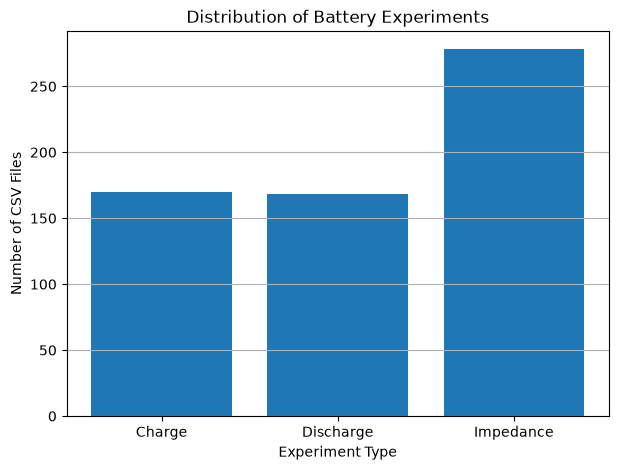

In [13]:
plt.figure(figsize=(7,5))

plt.bar(
    summary["Experiment"],
    summary["Files"]
)

plt.title("Distribution of Battery Experiments")
plt.xlabel("Experiment Type")
plt.ylabel("Number of CSV Files")

plt.grid(axis="y")

plt.show()

## Percentage Distribution

In [14]:
summary["Percentage"] = (
    summary["Files"] /
    summary["Files"].sum()
) * 100

summary

,Experiment,Files,Percentage
0,Charge,170,27.597403
1,Discharge,168,27.272727
2,Impedance,278,45.129870


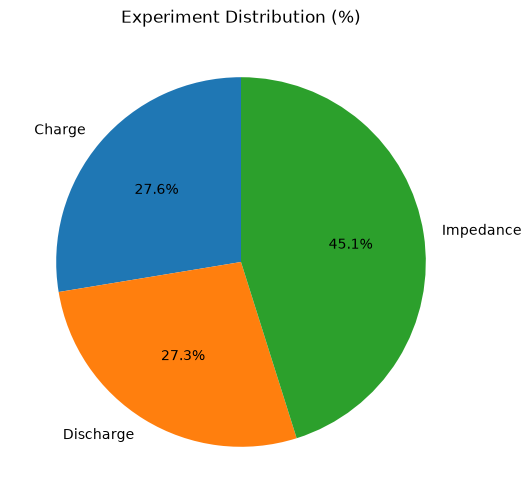

In [15]:
plt.figure(figsize=(6,6))

plt.pie(
    summary["Files"],
    labels=summary["Experiment"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Experiment Distribution (%)")

plt.show()

## Verify Sample Processed Files

In [16]:
charge_df = pd.read_csv(charge_files[0])
charge_df.head()

,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time
0,3.325055,0.000302,29.341851,-0.002,0.003,0.000
1,3.001951,-3.361983,29.335723,-3.370,1.414,2.516
2,3.434644,1.508670,29.334717,1.498,4.142,5.500
3,3.454857,1.510043,29.341949,1.498,4.180,8.391
4,3.468788,1.508704,29.331462,1.498,4.196,11.266


In [17]:
discharge_df = pd.read_csv(discharge_files[0])
discharge_df.head()

,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.191492,-0.004902,24.330034,-0.0006,0.000,0.000
1,4.190749,-0.001478,24.325993,-0.0006,4.206,16.781
2,3.974871,-2.012528,24.389085,-1.9982,3.062,35.703
3,3.951717,-2.013979,24.544752,-1.9982,3.030,53.781
4,3.934352,-2.011144,24.731385,-1.9982,3.011,71.922


In [18]:
impedance_df = pd.read_csv(impedance_files[0])
impedance_df.head()

,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance
0,(-1+1j),(-1+1j),(1+0j),(-0.43892624830326377-0.107298295835479j),(0.07006937798290404-0.00047998469078178944j)
1,(820.6094970703125-36.23455047607422j),(337.0914611816406-82.9207763671875j),(2.3204145178633437+0.4633045948164565j),(0.13008840651776496-0.19711481029612374j),(0.06817886114940203-0.001190040925296937j)
2,(827.2421875-48.23122787475586j),(330.6315612792969-70.01371765136719j),(2.424192647592199+0.36746495469515333j),(0.058770560504133235+0.03330656583655633j),(0.06793257733714593-5.6826811936507056e-05j)
3,(827.1934814453125-56.195716857910156j),(330.8086242675781-61.73442459106445j),(2.4470021712116985+0.28677775364826635j),(0.0058135116366746726-0.060546548141956195j),(0.06691839226387165-0.0008787264015490232j)
4,(824.9295043945312-53.241477966308594j),(332.68267822265625-57.62901306152344j),(2.434304977711638+0.2616460702282485j),(0.12608106668700975-0.09044390544679616j),(0.06807105294348659-0.0001974802021297548j)


# Conclusions

The preprocessing pipeline successfully:

- Loaded all selected NASA battery experiments.
- Classified every CSV into Charge, Discharge or Impedance.
- Removed duplicate records.
- Saved cleaned datasets into the processed directory.
- Verified that all processed files are readable.
- Generated summary statistics and visualizations.

The processed dataset is now ready for feature engineering and machine learning model development.